# **Machine Learning Homework** - Combining Evolutionary Learning, Active Learning and Ensemble Learning to solve the Higgs Bozon Detection
MARCELINO Auriane

## Sommaire
- [Preprocessing](#i---dataset-preprocessing)
    - [1. Import](#1-import-csv-file)
    - [2. Delete columns](#2-delete-superfluous-columns)
    - [3. Transform label](#3-transform-label)
    - [4. Check data repartition](#4-check-data-repartition)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn import model_selection
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import operator
import math
from deap import gp
import random

## Dataset preprocessing

### 1. Import CSV file

In [2]:
atlas = pd.read_csv('atlas-higgs.csv')
# I create a copy of the data to work on it, and I keep the original one safe to avoid re-importing it if there is a problem
data = atlas.copy()
print(data.shape)
print(data.dtypes)
data.head()

(818238, 35)
EventId                          int64
DER_mass_MMC                   float64
DER_mass_transverse_met_lep    float64
DER_mass_vis                   float64
DER_pt_h                       float64
DER_deltaeta_jet_jet           float64
DER_mass_jet_jet               float64
DER_prodeta_jet_jet            float64
DER_deltar_tau_lep             float64
DER_pt_tot                     float64
DER_sum_pt                     float64
DER_pt_ratio_lep_tau           float64
DER_met_phi_centrality         float64
DER_lep_eta_centrality         float64
PRI_tau_pt                     float64
PRI_tau_eta                    float64
PRI_tau_phi                    float64
PRI_lep_pt                     float64
PRI_lep_eta                    float64
PRI_lep_phi                    float64
PRI_met                        float64
PRI_met_phi                    float64
PRI_met_sumet                  float64
PRI_jet_num                      int64
PRI_jet_leading_pt             float64
PRI_jet_lead

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label,KaggleSet,KaggleWeight
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,2.150,0.444,46.062,1.24,-2.475,113.497,0.000814,s,t,0.002653
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,0.725,1.158,-999.000,-999.00,-999.000,46.226,0.681042,b,t,2.233584
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,2.053,-2.028,-999.000,-999.00,-999.000,44.251,0.715742,b,t,2.347389
3,100003,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,...,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,1.660654,b,t,5.446378
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,1.904263,b,t,6.245333


### 2. Delete superfluous columns

We delete some columns that are not usefull

In [3]:
del(data['EventId'])
del(data['Weight'])
del(data['KaggleSet'])
del(data['KaggleWeight'])

### 3. Transform label

We simplify the *Label* column, replacing the value by 1 if it's a 's' (for 'signal'), and 0 if it's a 'b' (for 'background')

In [4]:
data['Label'] = data['Label'].apply(lambda x: 1 if x == 's' else 0)

### 4. Check data repartition

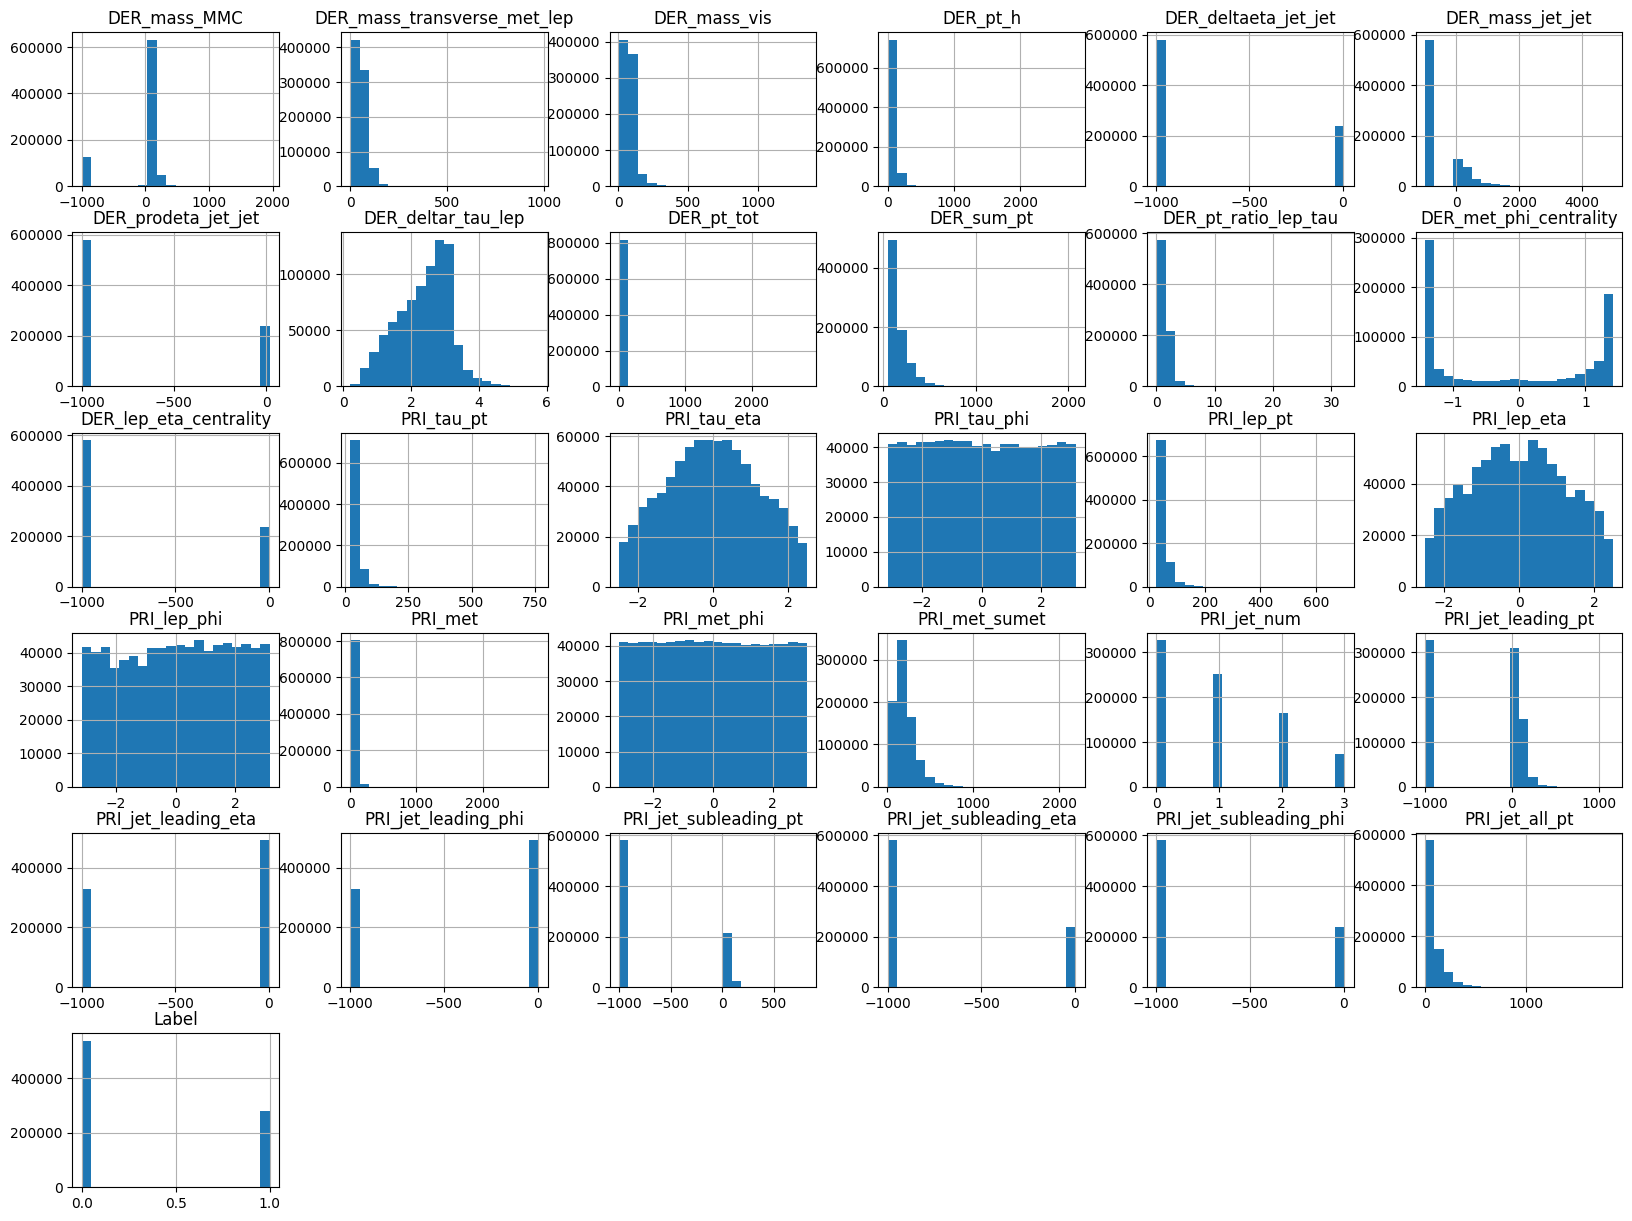

In [5]:
data.hist(bins = 20, figsize = (20,15))
plt.show()

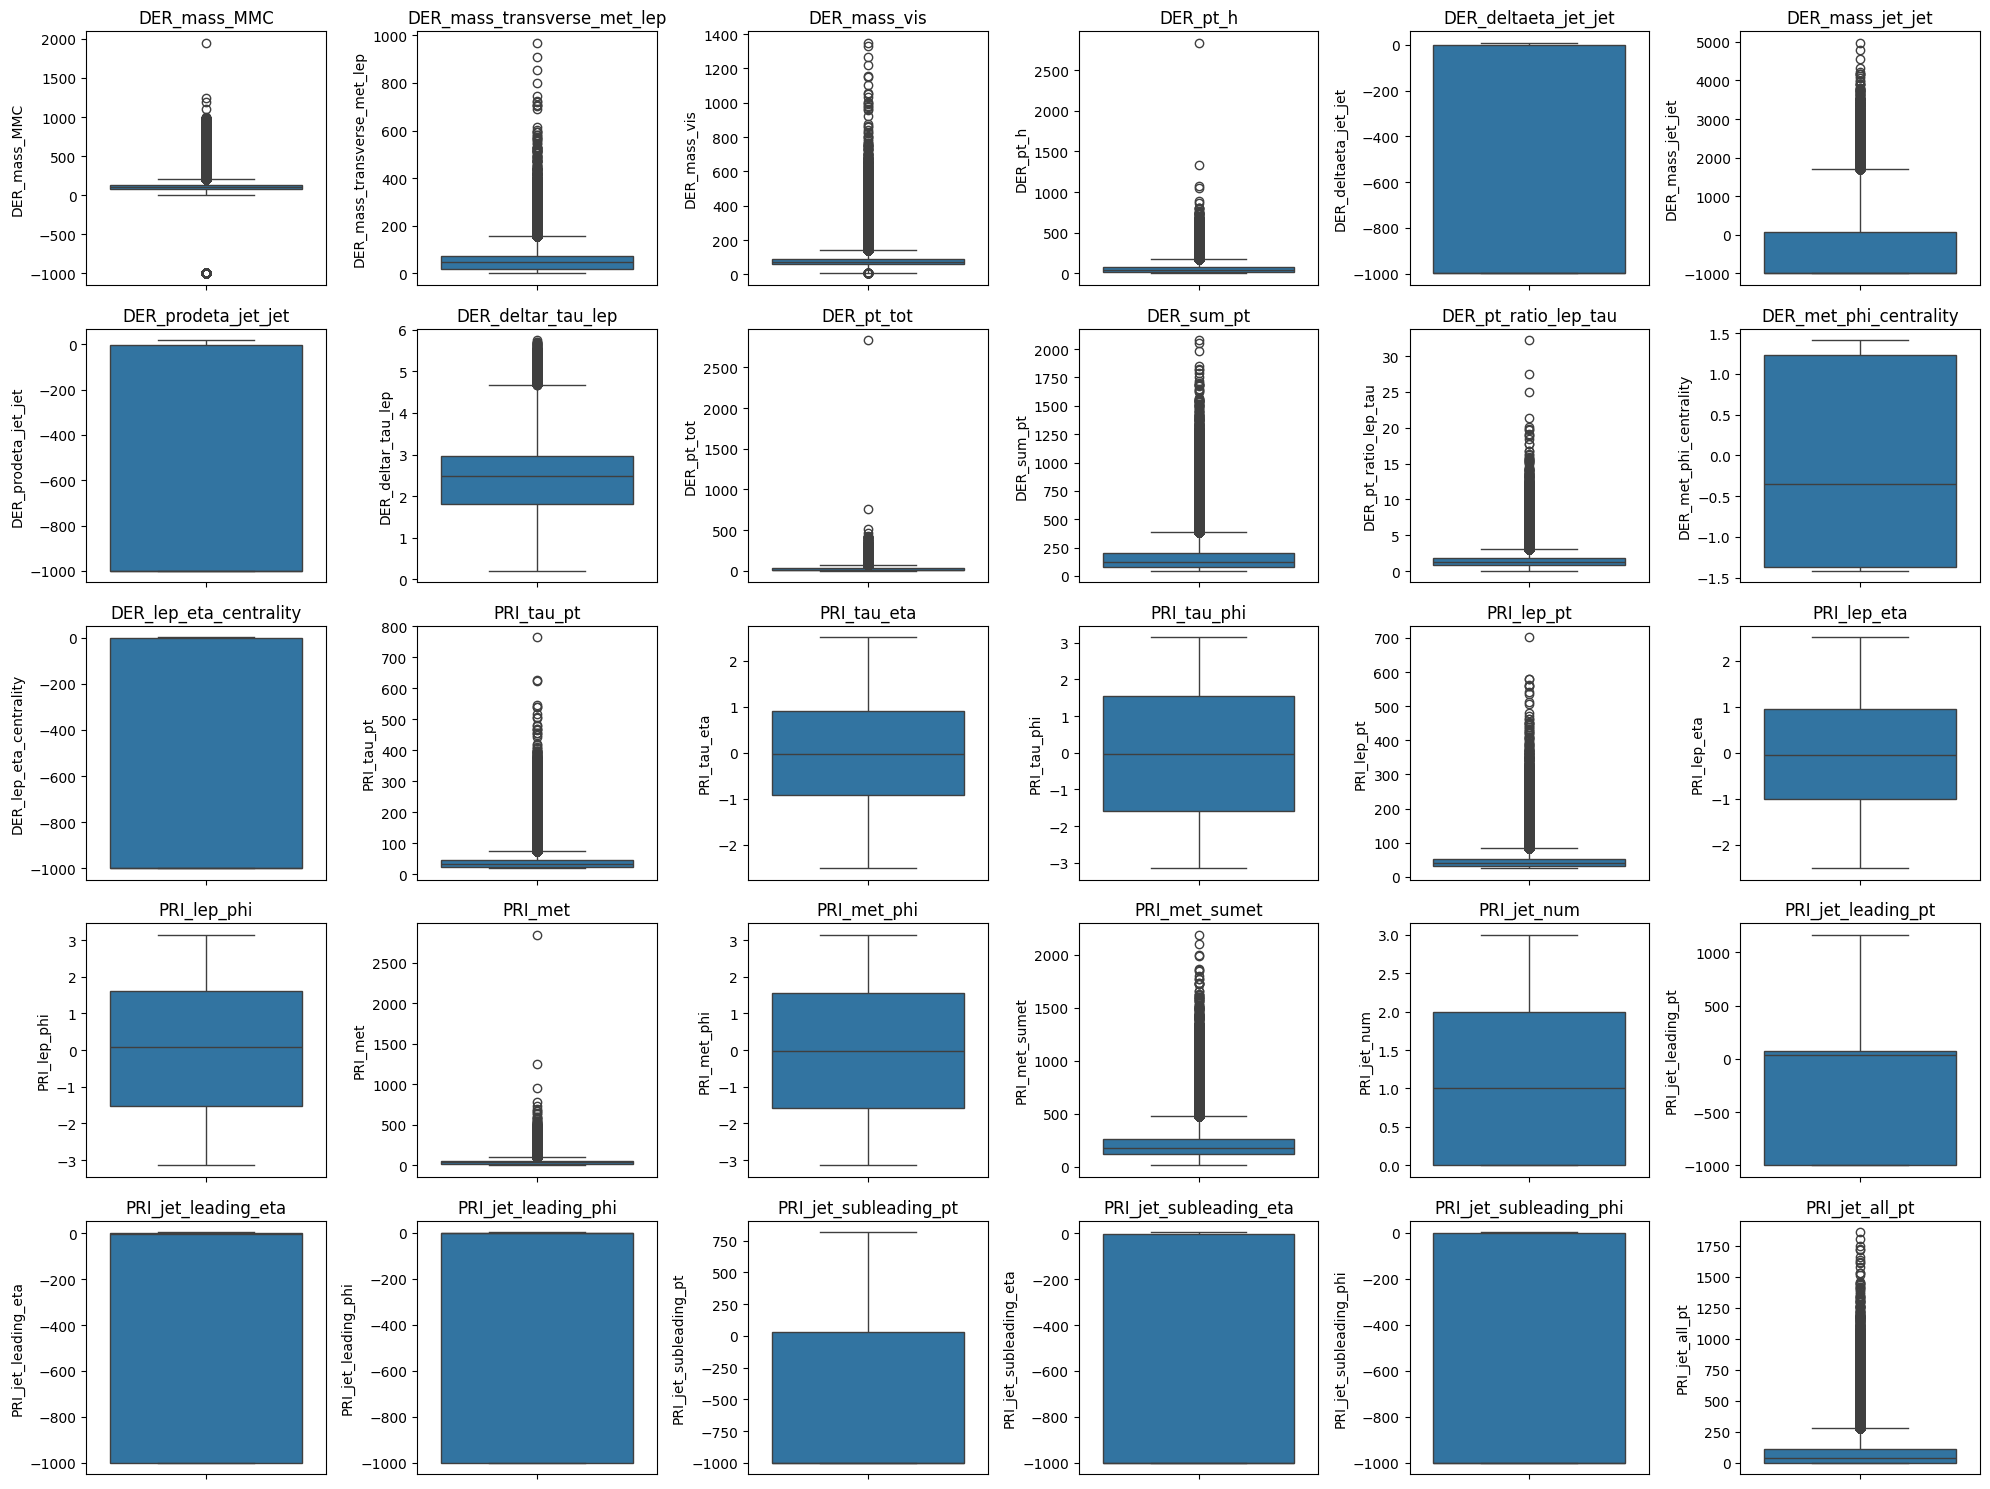

In [6]:
plt.figure(figsize=(20,15))
for i, column in enumerate(data.drop(columns=['Label']).columns):
    plt.subplot(5, 6, i + 1)
    sns.boxplot(y=data.drop(columns=['Label'])[column])
    plt.title(column)
plt.tight_layout()
plt.show()

### 5. Correlation

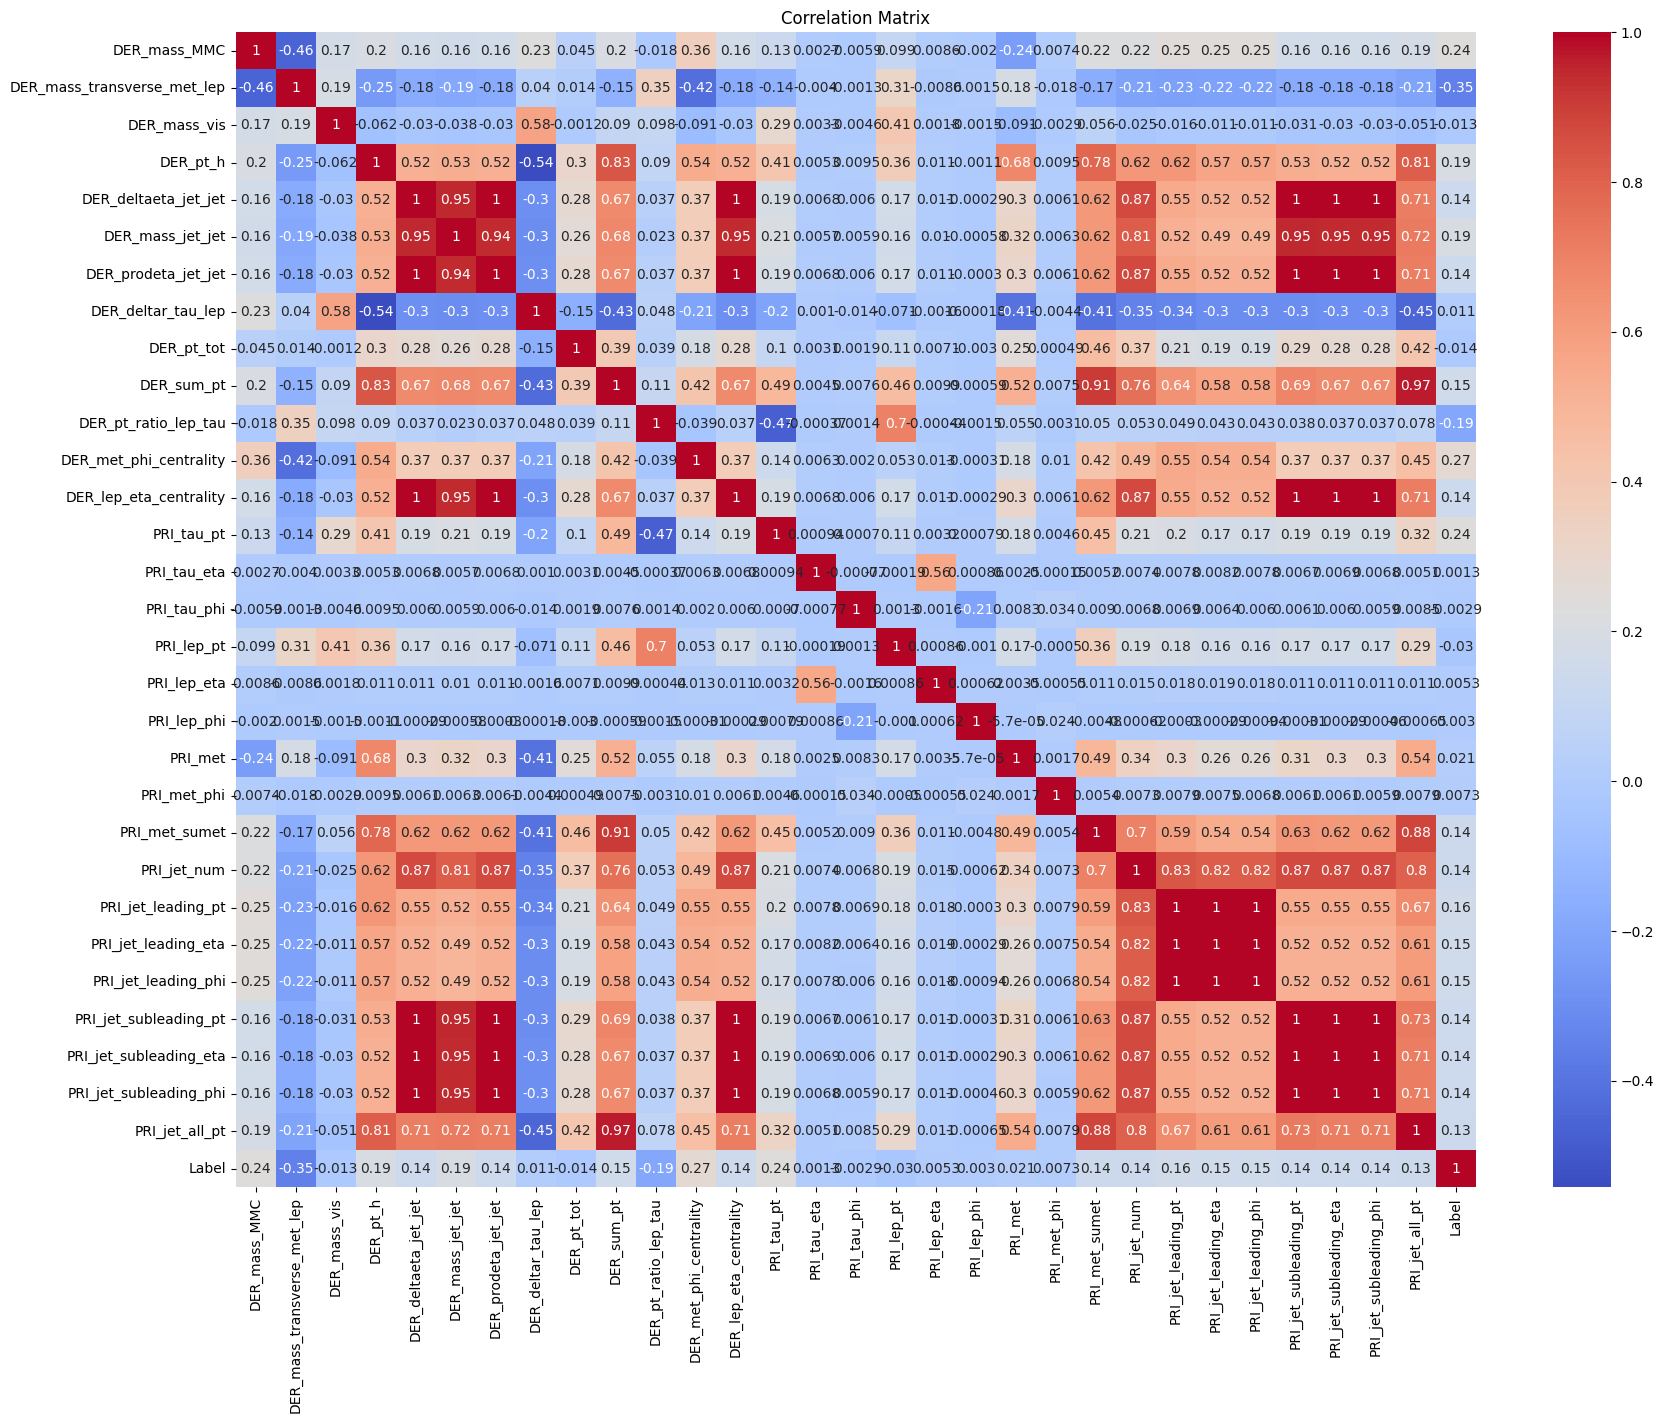

In [7]:
corr_mat=pd.DataFrame(data, columns=data.columns).corr()
plt.figure(figsize=(20,15))
sns.heatmap(corr_mat,annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### 6. Check for missing values

In [8]:
print("--------- NULL VALUES (%) --------", data.isnull().sum() / data.shape[0] * 100, sep='\n')
print("\n------------ -999 VALUES (%) -----------", (data == -999.0).sum() / data.shape[0] * 100, sep='\n')

--------- NULL VALUES (%) --------
DER_mass_MMC                   0.0
DER_mass_transverse_met_lep    0.0
DER_mass_vis                   0.0
DER_pt_h                       0.0
DER_deltaeta_jet_jet           0.0
DER_mass_jet_jet               0.0
DER_prodeta_jet_jet            0.0
DER_deltar_tau_lep             0.0
DER_pt_tot                     0.0
DER_sum_pt                     0.0
DER_pt_ratio_lep_tau           0.0
DER_met_phi_centrality         0.0
DER_lep_eta_centrality         0.0
PRI_tau_pt                     0.0
PRI_tau_eta                    0.0
PRI_tau_phi                    0.0
PRI_lep_pt                     0.0
PRI_lep_eta                    0.0
PRI_lep_phi                    0.0
PRI_met                        0.0
PRI_met_phi                    0.0
PRI_met_sumet                  0.0
PRI_jet_num                    0.0
PRI_jet_leading_pt             0.0
PRI_jet_leading_eta            0.0
PRI_jet_leading_phi            0.0
PRI_jet_subleading_pt          0.0
PRI_jet_subleading_e

There is no null values in any column, however, in this dataset, missing values are designed by -999.0

I replace them using `SimpleImputer`

In [9]:
data = data.replace(-999.0, np.nan)
missing_cols = data.columns[data.isnull().mean() > 0.5]
data = data.drop(columns=missing_cols)

imputer = SimpleImputer(strategy='median')
data = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)

### 7. Data scaling

In [10]:
X = data.drop(columns=['Label']).values
y = data['Label'].values

scaler = MinMaxScaler()
data_normalized = pd.DataFrame(scaler.fit_transform(X), columns=data.drop(columns = ["Label"]).columns)
data_normalized['Label'] = y

In [11]:
data.head()

,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltar_tau_lep,DER_pt_tot,DER_sum_pt,DER_pt_ratio_lep_tau,DER_met_phi_centrality,PRI_tau_pt,...,PRI_lep_phi,PRI_met,PRI_met_phi,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_all_pt,Label
0,138.470,51.655,97.827,27.980,3.064,41.928,197.760,1.582,1.396,32.638,...,-2.414,16.824,-0.277,258.733,2.0,67.435,2.150,0.444,113.497,1.0
1,160.937,68.768,103.235,48.146,3.473,2.078,125.157,0.879,1.414,42.014,...,0.103,44.704,-1.916,164.546,1.0,46.226,0.725,1.158,46.226,0.0
2,112.501,162.172,125.953,35.635,3.148,9.336,197.814,3.776,1.414,32.154,...,1.052,54.283,-2.186,260.414,1.0,44.251,2.053,-2.028,44.251,0.0
3,143.905,81.417,80.943,0.414,3.310,0.414,75.968,2.354,-1.285,22.647,...,-3.100,31.082,0.060,86.062,0.0,65.760,0.000,-0.044,-0.000,0.0
4,175.864,16.915,134.805,16.405,3.891,16.405,57.983,1.056,-1.385,28.209,...,1.569,2.723,-0.871,53.131,0.0,65.760,0.000,-0.044,0.000,0.0


In [12]:
data_normalized.head()

,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltar_tau_lep,DER_pt_tot,DER_sum_pt,DER_pt_ratio_lep_tau,DER_met_phi_centrality,PRI_tau_pt,...,PRI_lep_phi,PRI_met,PRI_met_phi,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_all_pt,Label
0,0.066707,0.053326,0.068128,0.009869,0.515244,0.014789,0.074595,0.047699,0.993635,0.016977,...,0.115850,0.005901,0.455920,0.112586,0.666667,0.033028,0.738889,0.570656,0.061014,1.0
1,0.078287,0.070992,0.072155,0.016983,0.589031,0.000733,0.038884,0.025854,1.000000,0.029572,...,0.516391,0.015709,0.195099,0.069314,0.333333,0.014316,0.580556,0.684278,0.024850,0.0
2,0.053322,0.167417,0.089071,0.012570,0.530399,0.003293,0.074622,0.115876,1.000000,0.016327,...,0.667409,0.019079,0.152132,0.113359,0.333333,0.012573,0.728111,0.177276,0.023789,0.0
3,0.069508,0.084050,0.055557,0.000146,0.559625,0.000146,0.014690,0.071688,0.045615,0.003556,...,0.006684,0.010917,0.509548,0.033256,0.000000,0.031550,0.500000,0.492998,0.000000,0.0
4,0.085980,0.017462,0.095662,0.005787,0.664442,0.005787,0.005843,0.031354,0.010255,0.011028,...,0.749682,0.000940,0.361394,0.018126,0.000000,0.031550,0.500000,0.492998,0.000000,0.0


### 8. Split data

I separate the output to make some checks after (I do it before checking outlier because if I do it after, the outlier graph can plot 30 columns but we have 31 with the Label column)

In [13]:
X = data_normalized.drop('Label', axis=1)
y = data_normalized['Label']

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3, random_state=42)

print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(572766, 23) (245472, 23) (572766,) (245472,)


### 9. Check unbalanced ratio

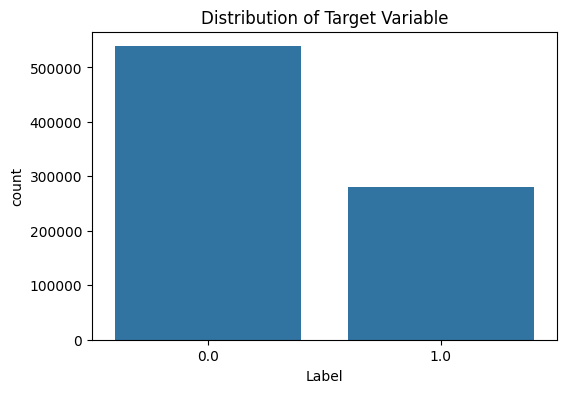

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='Label', data=data)
plt.title('Distribution of Target Variable')
plt.show()

We can see that the data is not exactly balanced, but both labels are well represented.

I decided to not balanced the data because i first did it using SMOTE and BSMOTE, but the execution of the notebook was too long. So to avoid wasting time doing something that is note mandatory in this case, I kept the data like this.

### 10. Dimensionality reduction

In [15]:
pca = PCA(n_components=0.90)
pca.fit(X_train)

#Transforming learning data
X_train = pca.transform(X_train)
X_test = pca.transform(X_test)
print(X_train.shape, X_test.shape)

(572766, 8) (245472, 8)


### 11. Pipeline

In [16]:
# preprocessing_pipeline = Pipeline(steps=[
#     ('imputer', SimpleImputer(missing_values=-999, strategy='mean')),
#     ('scaler', MinMaxScaler()),
#     ('pca', PCA(n_components=0.90))
# ])

# preprocessing_pipeline.fit(X_train)
# X_train = preprocessing_pipeline.transform(X_train)
# X_test = preprocessing_pipeline.transform(X_test)
# print(X_train.shape, X_test.shape)

## I - Evolutionary Learning with DEAP

In [17]:
import random
import operator
import numpy as np
from deap import base, creator, tools, gp, algorithms
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

#### 1. Set up DEAP components

In [ ]:
n_features = X_train.shape[1]

# Create a Primitive Set. "MAIN" is the name, n_features is the number of inputs (ARG0, ARG1...)
pset = gp.PrimitiveSet("MAIN", n_features)

# Add arithmetic operators (Genetic Program nodes)
pset.addPrimitive(np.add, 2)
pset.addPrimitive(np.subtract, 2)
pset.addPrimitive(np.multiply, 2)
pset.addPrimitive(np.negative, 1)

# Add protected division to avoid division by zero errors
def protectedDiv(left, right):
    # Avoid division by zero
    if right == 0:
        return 1
    return left / right

def protectedLog(x):
    # Avoid log of 0 or negative numbers
    if x == 0:
        return 0
    return np.log(abs(x))

def protectedSqrt(x):
    # Avoid square root of negative numbers by taking absolute value first
    return np.sqrt(abs(x))

pset.addPrimitive(protectedDiv, 2)
pset.addPrimitive(operator.neg, 1)
pset.addPrimitive(operator.abs, 1)
pset.addPrimitive(protectedSqrt, 1)
pset.addPrimitive(protectedLog, 1)
pset.addPrimitive(math.cos, 1)
pset.addPrimitive(math.sin, 1)
pset.addPrimitive(np.tanh, 1)

# Add ephemeral constants (random numbers that can be part of the formula)
pset.addEphemeralConstant("rand101", lambda: random.randint(-1, 1))

# Rename arguments to x0, x1, etc. for better readability
pset.renameArguments(**{f"ARG{i}": f"x{i}" for i in range(n_features)})


# 1. Fitness Function: We want to Maximize Accuracy (weight = 1.0)
# If you wanted to maximize F1 score, you could use that too.
if hasattr(creator, "FitnessMax"): del creator.FitnessMax
creator.create("FitnessMax", base.Fitness, weights=(1.0,))

# 2. Individual: A Tree structure
if hasattr(creator, "Individual"): del creator.Individual
creator.create("Individual", gp.PrimitiveTree, fitness=creator.FitnessMax)

# 3. Toolbox
toolbox = base.Toolbox()
toolbox.register("expr", gp.genHalfAndHalf, pset=pset, min_=1, max_=3) # Tree generation strategy
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.expr)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("compile", gp.compile, pset=pset)

c:\Users\auria\AppData\Local\Programs\Python\Python312\Lib\site-packages\deap\gp.py:257: RuntimeWarning: Ephemeral rand101 function cannot be pickled because its generating function is a lambda function. Use functools.partial instead.
  warnings.warn("Ephemeral {name} function cannot be "


#### 2. Evaluation function

In [19]:
def evalSymbReg(individual, X, y):
    # Compile the tree expression into a callable function
    func = toolbox.compile(expr=individual)
    
    # Apply the function to the input data
    # We transpose X (.T) because the function expects arguments x0, x1... 
    # and numpy can broadcast these operations if inputs are arrays.
    try:
        result = func(*X.T) 
    except Exception:
        # If the generated formula is invalid (e.g. overflow), give bad fitness
        return 0,

    # Convert continuous output to class labels (0 or 1)
    # Sigmoid-like logic: if result > 0 predict 1 (Signal), else 0 (Background)
    # Ensure result is a numpy array
    if isinstance(result, np.ndarray):
        predictions = (result > 0).astype(int)
    else:
        # If result is a single scalar (rare but possible with constant trees), broadcast it
        predictions = np.full(y.shape, int(result > 0))
        
    return f1_score(y, predictions),

# Register the evaluation function
toolbox.register("evaluate", evalSymbReg, X=X_train, y=y_train)

I chose f1_score over accuracy_score because with accuracy, I obtained a f1 score of 0 and an accuracy of 0.658 because the models always predicted background (label = 0) which is present in the dataset at 65.8%.

#### 3. Genetic Operators

In [20]:
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("mate", gp.cxOnePoint)
toolbox.register("expr_mut", gp.genFull, min_=0, max_=2)
toolbox.register("mutate", gp.mutUniform, expr=toolbox.expr_mut, pset=pset)

# Decorators to limit tree height (prevents bloat)
toolbox.decorate("mate", gp.staticLimit(key=operator.attrgetter("height"), max_value=17))
toolbox.decorate("mutate", gp.staticLimit(key=operator.attrgetter("height"), max_value=17))

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from deap import tools, algorithms
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# --- 1. Fix Data Formats (Crucial for Active Learning) ---
# Active Learning uses index slicing which fails on Pandas Series if indices aren't reset.
# We convert everything to NumPy arrays to be safe.

# Assuming X_train, y_train, X_test, y_test exist from your Part 1
X_train_np = np.array(X_train)
y_train_np = np.array(y_train)
X_test_np = np.array(X_test)
y_test_np = np.array(y_test)

# --- 2. Setup Active Learning Pools ---
# Split training data: 5% Labeled (Start), 95% Unlabeled (Pool)
X_labeled, X_unlabeled, y_labeled, y_unlabeled = train_test_split(
    X_train_np, y_train_np, 
    train_size=0.05, 
    random_state=42, 
    stratify=y_train_np
)

print(f"Data Prepared:")
print(f"Initial Labeled Set: {X_labeled.shape[0]} samples")
print(f"Unlabeled Pool: {X_unlabeled.shape[0]} samples")

# --- 3. Define Uncertainty Sampling Function ---
def uncertainty_sampling(model_func, X_pool, n_instances=100):
    """Selects the instances where the model is most uncertain (outputs close to 0)."""
    try:
        # Try vectorized prediction (fast)
        raw_predictions = model_func(*X_pool.T)
    except:
        # Fallback to row-by-row (slower but safer)
        raw_predictions = [model_func(*row) for row in X_pool]
    
    raw_predictions = np.array(raw_predictions)
    
    # Uncertainty = |prediction - 0| (Distance to decision boundary)
    # Smallest distance = Most uncertain
    distance = np.abs(raw_predictions)
    
    # Get indices of the smallest distances
    uncertain_indices = np.argsort(distance)[:n_instances]
    return uncertain_indices

# --- 4. Setup DEAP Statistics ---
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("min", np.min)
stats.register("max", np.max)

Data Prepared:
Initial Labeled Set: 28638 samples
Unlabeled Pool: 544128 samples


#### Run

In [22]:
def main():
    random.seed(42)
    pop = toolbox.population(n=100) 
    hof = tools.HallOfFame(1) # Store the best individual
    
    stats_fit = tools.Statistics(lambda ind: ind.fitness.values)
    stats_size = tools.Statistics(len)
    mstats = tools.MultiStatistics(fitness=stats_fit, size=stats_size)
    mstats.register("avg", np.mean)
    mstats.register("std", np.std)
    mstats.register("min", np.min)
    mstats.register("max", np.max)
    
    pop, log = algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.1, ngen=40, 
                                   stats=mstats, halloffame=hof, verbose=True)
    
    return pop, log, hof

# Run it
pop, log, hof = main()

   	      	                            fitness                             	                      size                     
   	      	----------------------------------------------------------------	-----------------------------------------------
gen	nevals	avg     	gen	max     	min	nevals	std     	avg 	gen	max	min	nevals	std    
0  	100   	0.243076	0  	0.536681	0  	100   	0.232634	3.12	0  	7  	2  	100   	1.27499
1  	51    	0.373584	1  	0.536681	0  	51    	0.197591	3.06	1  	8  	1  	51    	1.39871
2  	59    	0.422118	2  	0.549966	0  	59    	0.164835	3.35	2  	7  	1  	59    	1.40268
3  	64    	0.460306	3  	0.549966	0  	64    	0.138151	3.6 	3  	8  	2  	64    	1.64317
4  	53    	0.455413	4  	0.549966	0  	53    	0.154959	4.13	4  	10 	2  	53    	1.8366 
5  	52    	0.477429	5  	0.549966	0  	52    	0.140032	4.67	5  	9  	1  	52    	1.70326
6  	61    	0.479863	6  	0.549966	0  	61    	0.139369	4.95	6  	9  	1  	61    	1.60234
7  	56    	0.447096	7  	0.549966	0  	56    	0.19034 	4.72	7  	8  	1  	56

#### Test best model

In [23]:
best_ind = hof[0]
# print("Best Individual:", best_ind)
print("Best Training Accuracy:", best_ind.fitness.values[0])

# Compile and predict on Test Set
best_func = toolbox.compile(expr=best_ind)

precisions = []
accuracies = []
f1_scores = []
recall_scores = []

# Predict on test data
try:
    test_result = best_func(*X_test.T)
    if isinstance(test_result, np.ndarray):
        y_pred = (test_result > 0).astype(int)
    else:
        y_pred = np.full(y_test.shape, int(test_result > 0))
        
    # Calculate metrics
    print(f"Test Accuracy: {accuracy_score(y_test, y_pred)}")
    print(f"Test F1 Score: {f1_score(y_test, y_pred)}")
    print(f"Test Recall: {recall_score(y_test, y_pred)}")
    print(f"Test Precision: {precision_score(y_test, y_pred)}")
    accuracies.append(accuracy_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    recall_scores.append(recall_score(y_test, y_pred))
    precisions.append(precision_score(y_test, y_pred))
    
except Exception as e:
    print("Error applying best function to test set:", e)

Best Training Accuracy: 0.551827418208298
Test Accuracy: 0.6397308043279886
Test F1 Score: 0.5534121781988224
Test Recall: 0.6526555260430935
Test Precision: 0.48036714620098364


## II - Combining Active Learning with Evolutionary Learning (GA+AL)

In [24]:
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Split into labeled and unlabeled sets
X_labeled, X_unlabeled, y_labeled, y_unlabeled = train_test_split(
    X_train, y_train, train_size=0.05, random_state=42, stratify=y_train
)

# --- CRITICAL FIX: Convert to NumPy arrays ---
# This ensures that X[0] and y[0] always refer to the first item, 
# preventing the KeyError you are seeing.
X_labeled = np.array(X_labeled)
X_unlabeled = np.array(X_unlabeled)
y_labeled = np.array(y_labeled)
y_unlabeled = np.array(y_unlabeled)

print(f"Initial Training Size: {X_labeled.shape[0]}")
print(f"Unlabeled Pool Size: {X_unlabeled.shape[0]}")

Initial Training Size: 28638
Unlabeled Pool Size: 544128


In [25]:
def uncertainty_sampling(model_func, X_pool, n_instances=100):
    """
    Selects instances where the model is most uncertain (output close to 0).
    """
    # 1. Get raw predictions (floats) for the pool
    # Note: We assume model_func can accept a matrix. If not, loop through X_pool.
    raw_predictions = []
    # DEAP functions often expect unpacked arguments, depending on your compile settings.
    # If your best_func takes *args, you might need: best_func(*X_pool.T)
    # Adjust this line based on how your toolbox.compile works:
    try:
        raw_predictions = model_func(*X_pool.T)
    except:
        # Fallback if vectorization fails
        raw_predictions = [model_func(*row) for row in X_pool]
    
    raw_predictions = np.array(raw_predictions)
    
    # 2. Calculate uncertainty: distance from decision boundary (0)
    # Closer to 0 = higher uncertainty
    distance_to_boundary = np.abs(raw_predictions)
    
    # 3. Get indices of the 'n_instances' smallest distances
    # argsort returns indices that would sort the array (smallest first)
    uncertain_indices = np.argsort(distance_to_boundary)[:n_instances]
    
    return uncertain_indices

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from deap import tools, algorithms

# --- 1. SETUP STATISTICS ---
# This was missing in the previous snippet. 
# We track the 'fitness' (which is a tuple, so we need to extract the first value).
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("std", np.std)
stats.register("min", np.min)
stats.register("max", np.max)

# --- 2. ACTIVE LEARNING SETUP ---
n_iterations = 10     # How many times we query for new data
n_new_samples = 2000    # How many samples to add to the training set each time
ngen_per_loop = 40    # Generations to run GA inside each loop

# Initialize history lists to store performance metrics
history_f1 = []
history_accuracy = []
history_recall = []
history_precision = []
history_num_samples = []

print("--- Starting Active Learning ---")
print(f"Initial Labeled Size: {len(X_labeled)}")
print(f"Initial Unlabeled Size: {len(X_unlabeled)}")

pop = toolbox.population(n=100)
hof = tools.HallOfFame(1)

for i in range(n_iterations):
    print(f"\n=== AL Iteration {i+1} / {n_iterations} ===")
    print(f"Training on {len(X_labeled)} samples...")
    
    # Update evaluation function to use the CURRENT labeled set
    toolbox.register("evaluate", evalSymbReg, X=X_labeled, y=y_labeled)

    hof.clear()
    
    # Run GA for a few generations on this data
    # We pass the 'stats' object we defined above
    pop, log = algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.4, 
                                   ngen=ngen_per_loop, stats=stats, 
                                   halloffame=hof, verbose=False)
    
    # --- EVALUATE ON TEST SET ---
    # Pick the best individual from the Hall of Fame
    best_ind = hof[0]
    best_func = toolbox.compile(expr=best_ind)
    
    # Predict on the separate TEST set (not the pool!)
    # Note: Ensure X_test is defined from your earlier parts
    try:
        # Vectorized prediction
        test_raw = best_func(*X_test_np.T)
    except:
        # Fallback for non-vectorized
        test_raw = [best_func(*row) for row in X_test_np]
    
    test_raw = np.array(test_raw)
    
    # Convert raw output to binary class (Sig > 0, Bkg <= 0)
    # Adjust this threshold if you optimized it differently
    test_preds = np.where(test_raw > 0, 1, 0)
    
    # Calculate score (using F1 or Balanced Accuracy is best for Higgs)
    from sklearn.metrics import f1_score, accuracy_score
    current_score = f1_score(y_test_np, test_preds)
    current_accuracy = accuracy_score(y_test_np, test_preds)
    
    # Save metrics for plotting
    history_f1.append(current_score)
    history_accuracy.append(current_accuracy)
    history_recall.append(recall_score(y_test_np, test_preds))
    history_precision.append(precision_score(y_test_np, test_preds))
    history_num_samples.append(len(X_labeled))
    
    print(f"Current Test F1 Score: {current_score:.4f}")
    print(f"Current Test Accuracy: {current_accuracy:.4f}")

    # --- ACTIVE LEARNING SELECTION (Uncertainty Sampling) ---
    if len(X_unlabeled) > 0:
        idx_to_label = uncertainty_sampling(best_func, X_unlabeled, n_new_samples)
        
        # 4. Move data from Pool -> Labeled
        new_X = X_unlabeled[idx_to_label]
        new_y = y_unlabeled[idx_to_label]
        
        X_labeled = np.vstack([X_labeled, new_X])
        y_labeled = np.hstack([y_labeled, new_y])
        
        # Remove from unlabeled pool
        X_unlabeled = np.delete(X_unlabeled, idx_to_label, axis=0)
        y_unlabeled = np.delete(y_unlabeled, idx_to_label, axis=0)
        
        # 5. Invalidate fitness
        # Since the training data changed, old fitness values are now wrong.
        # We delete them so DEAP recalculates them in the next loop.
        for ind in pop:
            del ind.fitness.values

print("Active Learning Complete.")

--- Starting Active Learning ---
Initial Labeled Size: 28638
Initial Unlabeled Size: 544128

=== AL Iteration 1 / 10 ===
Training on 28638 samples...
Current Test F1 Score: 0.5550
Current Test Accuracy: 0.6497

=== AL Iteration 2 / 10 ===
Training on 30638 samples...
Current Test F1 Score: 0.5579
Current Test Accuracy: 0.6560

=== AL Iteration 3 / 10 ===
Training on 32638 samples...
Current Test F1 Score: 0.5598
Current Test Accuracy: 0.6626

=== AL Iteration 4 / 10 ===
Training on 34638 samples...
Current Test F1 Score: 0.5619
Current Test Accuracy: 0.6623

=== AL Iteration 5 / 10 ===
Training on 36638 samples...
Current Test F1 Score: 0.5623
Current Test Accuracy: 0.6539

=== AL Iteration 6 / 10 ===
Training on 38638 samples...
Current Test F1 Score: 0.5748
Current Test Accuracy: 0.6218

=== AL Iteration 7 / 10 ===
Training on 40638 samples...
Current Test F1 Score: 0.5779
Current Test Accuracy: 0.6068

=== AL Iteration 8 / 10 ===
Training on 42638 samples...
Current Test F1 Score: 0

In [27]:
accuracies.append(history_accuracy[-1])
f1_scores.append(history_f1[-1])
recall_scores.append(history_recall[-1])
precisions.append(history_precision[-1])

print(f"f1_score: {history_f1[-1]}")
print(f"accuracy: {history_accuracy[-1]}")
print(f"recall: {history_recall[-1]}")
print(f"precision: {history_precision[-1]}")

f1_score: 0.5866246045600758
accuracy: 0.6199240646591058
recall: 0.7884988744238122
precision: 0.46704905426094073


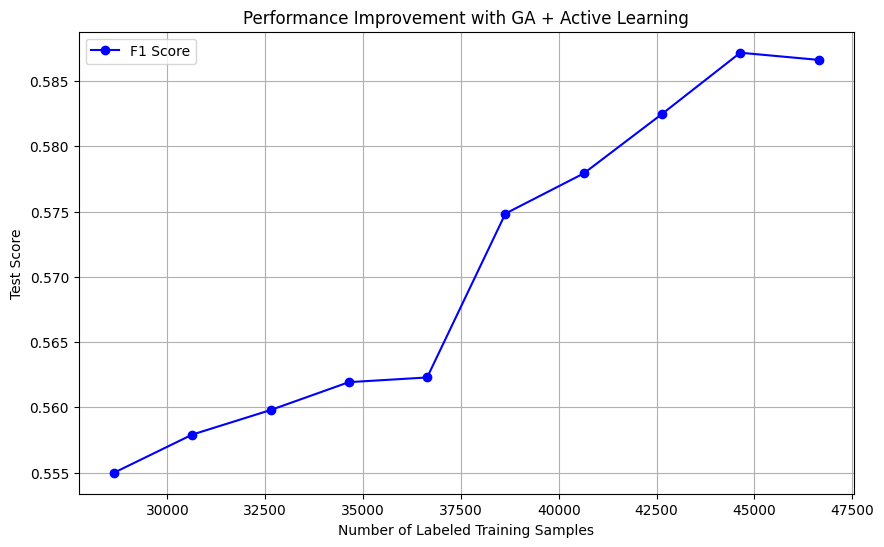

In [28]:
plt.figure(figsize=(10, 6))

# Plot Accuracy/F1 vs Number of Training Samples
plt.plot(history_num_samples, history_f1, marker='o', linestyle='-', color='b', label='F1 Score')
# plt.plot(history_num_samples, history_accuracy, marker='s', linestyle='--', color='g', label='Accuracy')
# plt.plot(history_num_samples, history_recall, marker='^', linestyle='-.', color='r', label='Recall')
# plt.plot(history_num_samples, history_precision, marker='x', linestyle=':', color='m', label='Precision')
plt.title('Performance Improvement with GA + Active Learning')
plt.xlabel('Number of Labeled Training Samples')
plt.ylabel('Test Score') # Or Accuracy, depending on what you logged
plt.grid(True)
plt.legend()

plt.show()

## III - Ensemble Learning (EL) Implementation : GA+AL+EL

In [29]:
# --- Ensemble Learning (Hard Voting) ---

# 1. Select Unique Individuals (Avoid Clones)
# We sort the population and pick the best ones that have unique equations.
k_ensemble = 21  # Target ensemble size (Odd number avoids ties)
unique_ensemble = []
seen_equations = set()

# Sort population by fitness (best first)
sorted_pop = tools.selBest(pop, len(pop))

for ind in sorted_pop:
    eqn = str(ind)
    if eqn not in seen_equations:
        unique_ensemble.append(ind)
        seen_equations.add(eqn)
    if len(unique_ensemble) >= k_ensemble:
        break

print(f"Ensemble constructed with {len(unique_ensemble)} unique models.")

# 2. Collect Votes
votes = []
for ind in unique_ensemble:
    func = toolbox.compile(expr=ind)
    try:
        preds = np.where(np.array(func(*X_test_np.T)) > 0, 1, 0)
    except:
        preds = np.where(np.array([func(*row) for row in X_test_np]) > 0, 1, 0)
    votes.append(preds)

# 3. Apply Majority Vote
if len(votes) > 0:
    votes_matrix = np.vstack(votes)
    sum_votes = np.sum(votes_matrix, axis=0)
    # If sum > half the ensemble size, predict 1, else 0
    y_pred_ensemble = np.where(sum_votes > (len(unique_ensemble) / 2), 1, 0)
    
    # 4. Calculate Ensemble Metrics
    el_f1 = f1_score(y_test_np, y_pred_ensemble)
    el_acc = accuracy_score(y_test_np, y_pred_ensemble)
    el_prec = precision_score(y_test_np, y_pred_ensemble)
    el_rec = recall_score(y_test_np, y_pred_ensemble)

    f1_scores.append(el_f1)
    accuracies.append(el_acc)
    recall_scores.append(el_rec)
    precisions.append(el_prec)
    
    print("\n=== Ensemble Results ===")
    print(f"Accuracy:  {el_acc:.4f}")
    print(f"F1 Score:  {el_f1:.4f}")
else:
    print("Error: No valid models found for ensemble.")

Ensemble constructed with 21 unique models.

=== Ensemble Results ===
Accuracy:  0.6206
F1 Score:  0.5867


## IV - Performance Metrics

In [30]:
f1_scores, accuracies, recall_scores, precisions

([0.5534121781988224, 0.5866246045600758, 0.5866902196104887],
 [0.6397308043279886, 0.6199240646591058, 0.620641050710468],
 [0.6526555260430935, 0.7884988744238122, 0.7872244124968734],
 [0.48036714620098364, 0.46704905426094073, 0.4675807033554768])

                 Method  F1 Score  Accuracies    Recall  Precision
0             Simple GA  0.553412    0.639731  0.652656   0.480367
1  GA + Active Learning  0.586625    0.619924  0.788499   0.467049
2    GA + AL + Ensemble  0.586690    0.620641  0.787224   0.467581


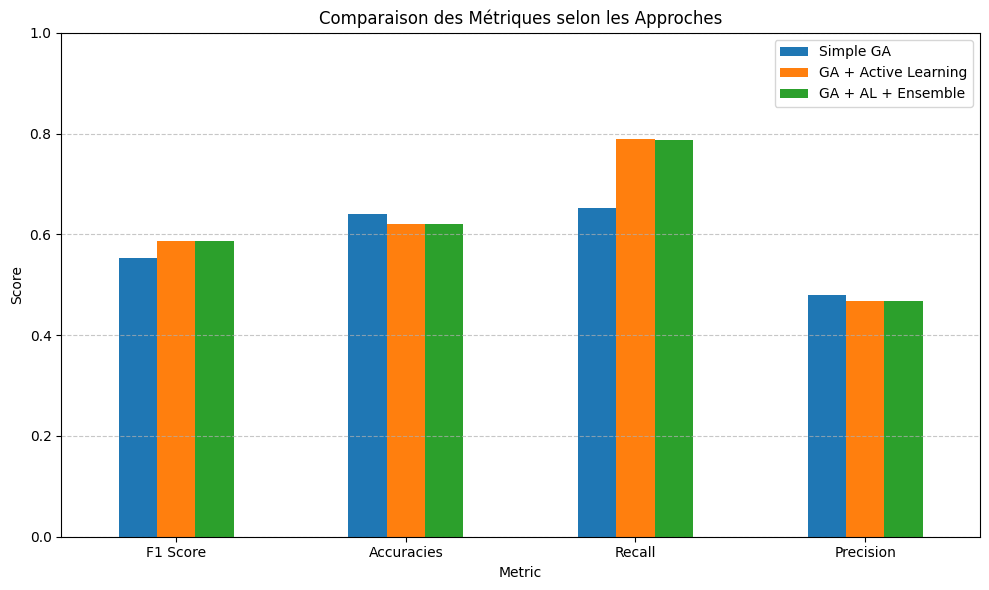

In [31]:
# Create a comparison dataframe
results_data = {
    "Method": ["Simple GA", "GA + Active Learning", "GA + AL + Ensemble"],
    "F1 Score": f1_scores,
    "Accuracies": accuracies,
    "Recall": recall_scores,
    "Precision": precisions,
    # "Evaluation": ["Trained on full data", "Iterative learning", "Voting mechanism"]
}

df_results = pd.DataFrame(results_data)
print(df_results)

df_transposed = df_results.set_index('Method').T.reset_index().rename(columns={'index': 'Metric'})

ax = df_transposed.plot(x='Metric', y=df_transposed.columns[1:], kind='bar', figsize=(10, 6), rot=0)
plt.title("Comparaison des Métriques selon les Approches")
plt.ylabel("Score")
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## V - Comparative Analysis